Notebook to work in! To load the dataset only one time

In [9]:
from LoadingDataset import *

df = loading_dataframe() 

print(df)


--Start loading dataset--
Trial: 20
Trial: 40
Trial: 60
--Finished loading dataset--
{'Trial_1':                                                            x  \
Track_1    (0.4915617336887338, 0.4888074121724598, 0.486...   
Track_2    (0.07535657655896169, 0.07526330296058384, 0.0...   
Track_3    (-0.006486002252066885, -0.004220824105546397,...   
Track_4    (0.021859353573039565, 0.022673805219507563, 0...   
Track_5    (0.19961463161498894, 0.19353493255753446, 0.1...   
...                                                      ...   
Track_763  (0.49595540066386967, 0.49420279223477853, 0.4...   
Track_764  (0.06221520056628922, 0.05901417153809262, 0.0...   
Track_765  (0.4872640757082221, 0.48428140313747137, 0.48...   
Track_766  (-0.005598267563186496, -0.0027471336071438323...   
Track_767  (-0.1295784532886579, -0.12693338723706607, -0...   

                                                           y  \
Track_1    (-0.3448935800538012, -0.3425020216992051, -0....   
Track_

Acces a track.

x --> df['Trial_1'].loc['Track_1'][0] or df['Trial_1'].loc['Track_1', 'x']

y --> df['Trial_1'].loc['Track_1'][1] or df['Trial_1'].loc['Track_1', 'z']

z --> df['Trial_1'].loc['Track_1'][2] or df['Trial_1'].loc['Track_1', 'y']

time --> df['Trial_1'].loc['Track_1'][3] or df['Trial_1'].loc['Track_1', 'time']

In [2]:
df['Trial_10'].loc['Track_6']

x       (-0.4802723191159874, -0.47263961920878894, -0...
y       (-0.028486223927734772, -0.02355766121061059, ...
z       (0.5484372752921228, 0.5438705716555217, 0.539...
time    (199.0888888888889, 199.1, 199.11111111111111,...
Name: Track_6, dtype: object

Added column that tells if the track has landed. 
To call the landed column: df['Trial_1']['landed']
Loop trhough this coumn: for track_name, landed_status in df['Trial_1']['landed'].items():
To ask if a specific track is landed: df['Trial_1'].loc['Track_1', 'landed'] --> true or false. 

Same goes for take-off

In [10]:
from supportive_functions import landing_area
for trial_num in range(1,65): 
    landed = []
    for track_name, track_data in df[f'Trial_{trial_num}'].iterrows():
        # Get last position and time values
        last_x = track_data['x'][-1]
        last_y = track_data['y'][-1]
        last_z = track_data['z'][-1]
        
        # Check if landed
        landed.append(landing_area(last_x, last_y, last_z))
        
    # Add the 'landed' column to the DataFrame (same value for all rows)
    trial_df = df[f'Trial_{trial_num}']
    trial_df['landed'] = landed
    df[f'Trial_{trial_num}'] = trial_df

for track_name, landed_status in df['Trial_1']['landed'].items():       
    if landed_status: 
        print(track_name, landed_status)

Track_34 True
Track_41 True
Track_43 True
Track_125 True
Track_134 True
Track_216 True
Track_265 True
Track_339 True
Track_386 True
Track_395 True
Track_449 True
Track_462 True
Track_463 True
Track_490 True
Track_516 True
Track_535 True
Track_550 True
Track_553 True
Track_568 True
Track_575 True
Track_576 True
Track_578 True
Track_593 True
Track_664 True
Track_682 True
Track_685 True
Track_687 True
Track_688 True
Track_689 True


In [11]:
from supportive_functions import landing_area
for trial_num in range(1,65): 
    take_off = []
    for track_name, track_data in df[f'Trial_{trial_num}'].iterrows():
        # Get last position and time values
        first_x = track_data['x'][0]
        first_y = track_data['y'][0]
        first_z = track_data['z'][0]
        
        # Check if landed
        take_off.append(landing_area(first_x, first_y, first_z))
        
    # Add the 'landed' column to the DataFrame (same value for all rows)
    trial_df = df[f'Trial_{trial_num}']
    trial_df['take_off'] = take_off
    df[f'Trial_{trial_num}'] = trial_df

count = 0 
for track_name, take_off_status in df['Trial_1']['take_off'].items():       
    if take_off_status: 
        count += 1
        print(track_name, take_off_status)
print(count)


Track_3 True
Track_4 True
Track_32 True
Track_213 True
Track_263 True
Track_264 True
Track_265 True
Track_287 True
Track_290 True
Track_293 True
Track_339 True
Track_349 True
Track_364 True
Track_379 True
Track_395 True
Track_400 True
Track_450 True
Track_452 True
Track_463 True
Track_476 True
Track_493 True
Track_516 True
Track_548 True
Track_550 True
Track_568 True
Track_569 True
Track_575 True
Track_576 True
Track_577 True
Track_578 True
Track_579 True
Track_593 True
Track_616 True
Track_618 True
Track_640 True
Track_664 True
Track_685 True
Track_687 True
Track_688 True
Track_689 True
Track_697 True
Track_700 True
42


Generating the pairs connecting the landings with the take-offs. 

In [13]:
radius = 0.2
for trial_num in range(1,65): 
    pairs=[]
    for track_name, track_data in df[f'Trial_{trial_num}'].iterrows():
        potentia_pairs = []
        if track_data['landed']: 
            last_x, last_y, last_z, last_time = track_data['x'][-1], track_data['y'][-1], track_data['z'][-1], track_data['time'][-1]
            print(last_x, last_time) 
            for track_name2, track_data2 in df[f'Trial_{trial_num}'].iterrows():
                first_x, first_y, first_z, first_time = track_data2['x'][0], track_data2['y'][0], track_data2['z'][0], track_data2['time'][0]

                dx, dy, dz, dtime = (last_x - first_x), (last_y - first_y), (
                                    last_z - first_z), (last_time - first_time)
                distance = np.sqrt((dx ** 2) + (dy ** 2) + (dz ** 2))
                if (distance < radius and dtime > 0):
                    potentia_pairs.append((distance,track_name, track_name2))

-0.1602259752023476 223.6888888888889
0.16269397633512606 231.05555555555554
0.028177022456167294 233.75555555555556
0.023749794295365334 332.75555555555553
0.14086178647530206 342.72222222222223
-0.0013009565344416774 474.1222222222222
0.17075102425845884 559.1555555555556
0.03546541228934513 686.2555555555556
0.10876998530744375 779.3111111111111
-0.0006096246630849234 789.1555555555556
0.15683465237211958 919.7555555555556
0.12987254884879024 961.8555555555556
0.14591733340560892 964.8333333333334
-0.010379540736194709 1053.2333333333333
0.14425476271968035 1139.8666666666666
0.15589496144401516 1224.1222222222223
0.10910983014021913 1320.0111111111112
0.16596580309248715 1321.2555555555555
0.1510249937710002 1424.4777777777779
0.1666618233396242 1499.6777777777777
0.12723012487546365 1506.3444444444444
0.007713753814426516 189.54444444444445
-0.011914994195673462 229.5222222222222
0.04354801292522714 542.3444444444444
-0.12753734467855715 743.3888888888889
0.17294655926256464 771.5

KeyboardInterrupt: 

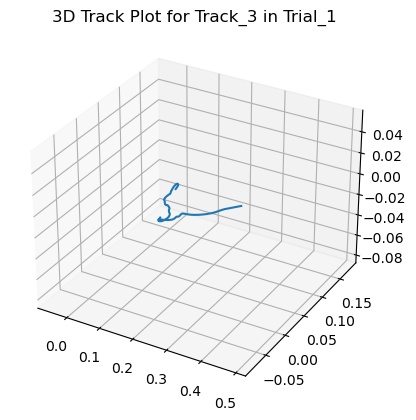

In [42]:
from matplotlib import pyplot as plt
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# Extract the data for Track_3
x = df['Trial_1'].loc['Track_3', 'x']
y = df['Trial_1'].loc['Track_3', 'y']
z = df['Trial_1'].loc['Track_3', 'z']

# Plot the 3D line
ax.plot(x, y, z)

ax.set_title('3D Track Plot for Track_3 in Trial_1')

plt.show()